<a href="https://colab.research.google.com/github/kkwong5443/datasharing/blob/master/immune_clustering_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Immune Matrix Clustering Analysis
This notebook performs hierarchical clustering and visualization of immune gene expression data.

In [7]:
%pwd

'/content'

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list

## Load Data

In [9]:
file_path = 'immune101_immune related gene__matrix.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')
df.head()

,Name,Category,OAAMPJ,OAAMPE,OAAMPC,OAAMOV,OAAMOS,OAAMOP,OAAMOO,OAAMOE,OAAMNU,OAAMNI,OAAMND,OAAMNA
0,CD2,T-cell lineage & differentiation,2.444078,0.243633,2.091110,4.038092,0.000000,4.597691,1.721547,1.501044,2.888285,5.005410,2.395717,3.413666
1,CD3D,T-cell lineage & differentiation,2.884492,0.179499,0.958671,1.837156,0.000000,2.544328,0.235493,0.044586,2.011026,4.259826,0.908464,4.579221
2,CD3E,T-cell lineage & differentiation,4.483800,2.190093,1.617145,3.477121,2.303503,4.996958,3.088542,1.700924,3.212443,5.840845,1.870587,5.931442
3,CD3G,T-cell lineage & differentiation,3.561990,0.956767,0.797711,2.201448,0.000000,2.812477,1.153337,0.982030,0.967409,3.797857,1.706950,4.533707
4,CD4,T-cell lineage & differentiation,4.643700,4.430355,4.285358,4.300409,1.804488,5.593524,4.266125,3.237004,4.958804,6.227378,5.255723,5.679663


## Extract Expression Matrix

In [10]:
sample_cols = df.columns[2:]
X = df[sample_cols]
X.shape

(101, 12)

## Sample Clustering

In [11]:
X_t = X.T
Z = linkage(X_t, method='ward')

## Dendrogram

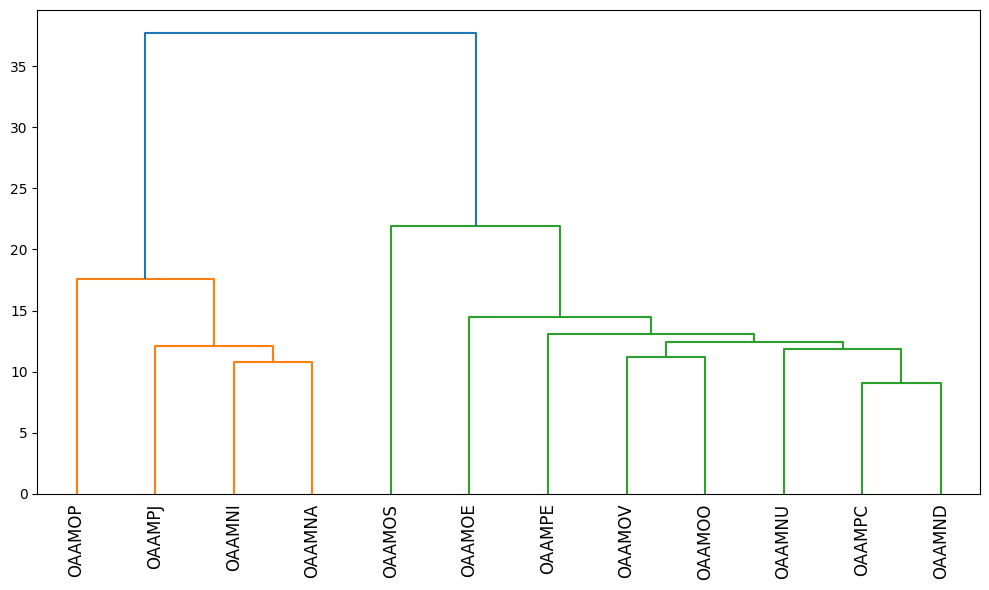

In [12]:
plt.figure(figsize=(10,6))
dendrogram(Z, labels=sample_cols, leaf_rotation=90)
plt.tight_layout()
plt.show()

## Select Top Variable Genes

In [13]:
top_idx = X.var(axis=1).sort_values(ascending=False).head(30).index
X_top = X.loc[top_idx]

## Normalize (Z-score)

In [14]:
X_scaled = (X_top - X_top.mean(axis=1).values.reshape(-1,1)) / X_top.std(axis=1).values.reshape(-1,1)

## Clustered Heatmap

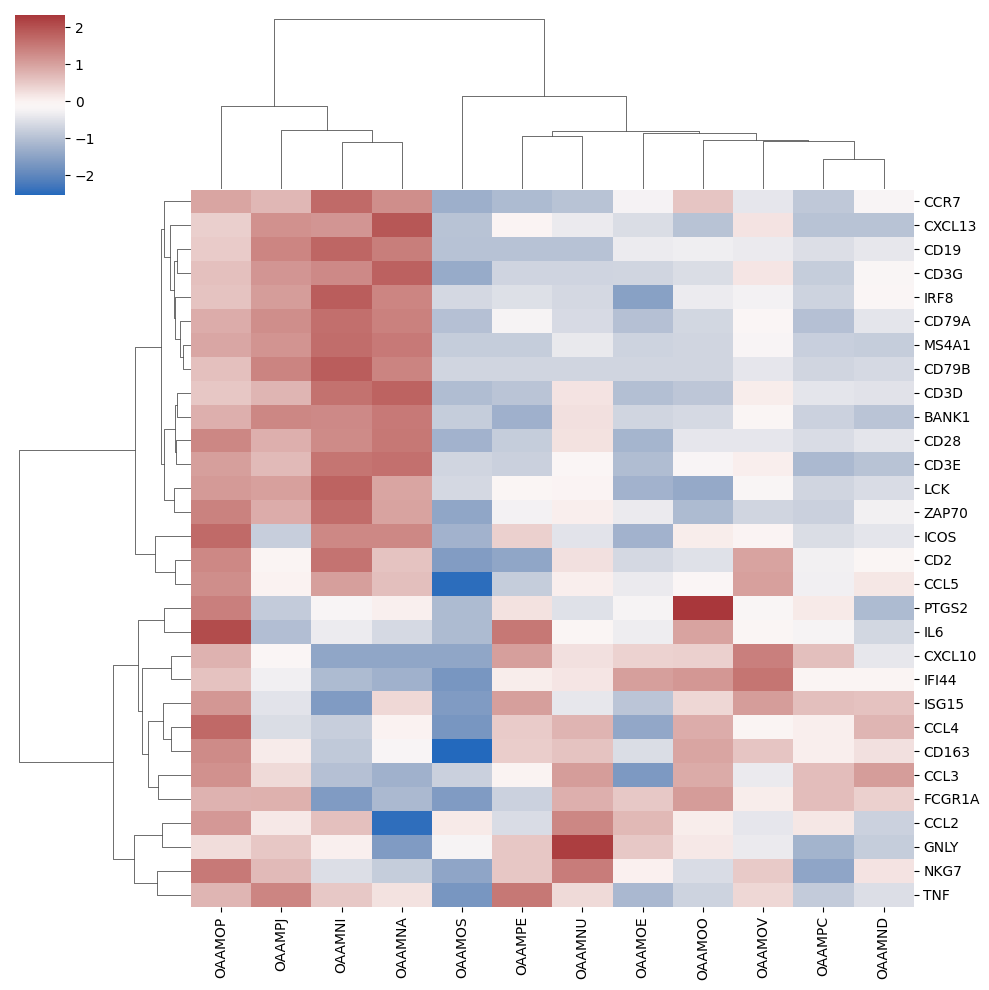

In [15]:
sns.clustermap(X_scaled, cmap='vlag', method='ward', metric='euclidean',
               yticklabels=df.loc[top_idx,'Name'], xticklabels=sample_cols, figsize=(10,10))
plt.show()

## Add Immune Category Annotation

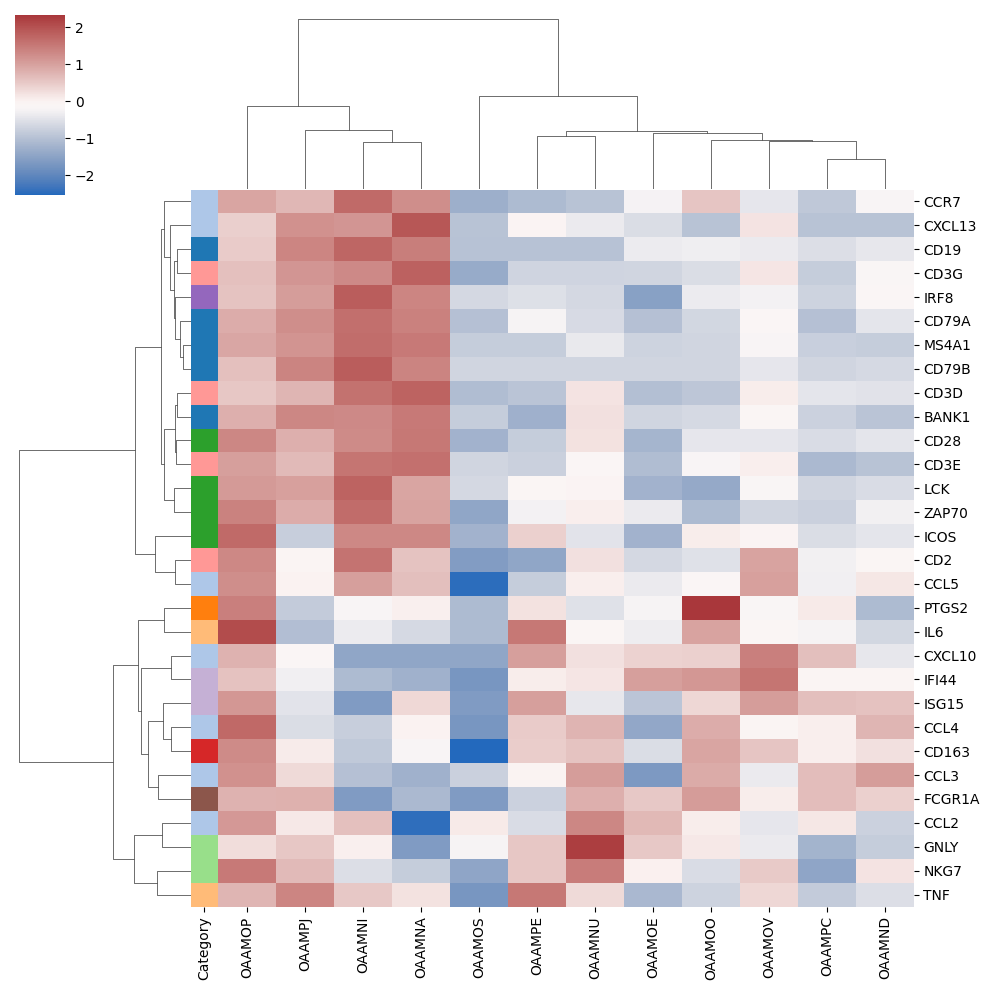

In [18]:
categories = df.loc[top_idx,'Category']
unique_cats = categories.unique()
palette = sns.color_palette('tab20', len(unique_cats))
cat_color_map = dict(zip(unique_cats, palette))
row_colors = categories.map(cat_color_map)
sns.clustermap(X_scaled, cmap='vlag', method='ward', metric='euclidean',
               yticklabels=df.loc[top_idx,'Name'], xticklabels=sample_cols,
               row_colors=row_colors, figsize=(10,10))
plt.show()